In [10]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph
import matplotlib.patches as patches

51182


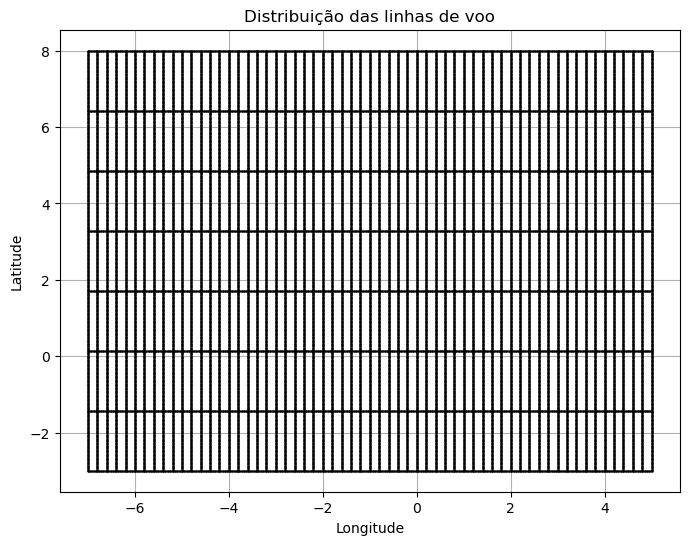

In [11]:
ellipsoid = bl.WGS84
 
region_airbone = [-7, 5, -3, 8]  

spacing_1 = (0.015, 0.2) 
coordinates_1 = vd.grid_coordinates(region=region_airbone, spacing=spacing_1, extra_coords= + 500)


spacing_2 = (1.5, 0.015) 
coordinates_2 = vd.grid_coordinates(region=region_airbone, spacing=spacing_2, extra_coords= + 500)


coordinates = np.concatenate((coordinates_1[0].ravel(), coordinates_2[0].ravel())), \
              np.concatenate((coordinates_1[1].ravel(), coordinates_2[1].ravel())), \
              np.concatenate((coordinates_1[2].ravel(), coordinates_2[2].ravel()))

print(coordinates[0].size)
plt.figure(figsize=(8, 6))
plt.plot(coordinates[0], coordinates[1], ".k", markersize=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição das linhas de voo")
plt.grid()
plt.show()

In [12]:
inclination, declination = 30, 20
noise_level = 0.1
# Syntetic dike

dike_size = 100
dike = sph.profile_points((1,-3), (5,1), dike_size,  - 4.0e4)
dike_2 =sph.profile_points((6,6), (0,8), dike_size,  - 4.0e4)

# Syntetic dipoles
n_dipoles = 4
dipoles = tuple(c.ravel() for c in vd.scatter_points(region= region_airbone, size= n_dipoles, extra_coords= - 2e4, random_state=2))

#Data

magnetic_field = sph.dipole_magnetic_geodetic(coordinates,
    dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(n_dipoles, 1e12),  
    np.full(n_dipoles, inclination),  
    np.full(n_dipoles, declination)   
)
)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_moments_dike = hm.magnetic_angles_to_vec(
    np.full(dike_size, -1e11),  
    np.full(dike_size, inclination),  
    np.full(dike_size, declination)   
)


magnetic_field = sph.dipole_magnetic_geodetic(coordinates, dike, magnetic_moments_dike)

magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_field = sph.dipole_magnetic_geodetic(coordinates, dike_2, magnetic_moments_dike)

magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)


# Add noise and the base level
magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-7.6), np.float64(5.6), np.float64(-3.55), np.float64(8.55))

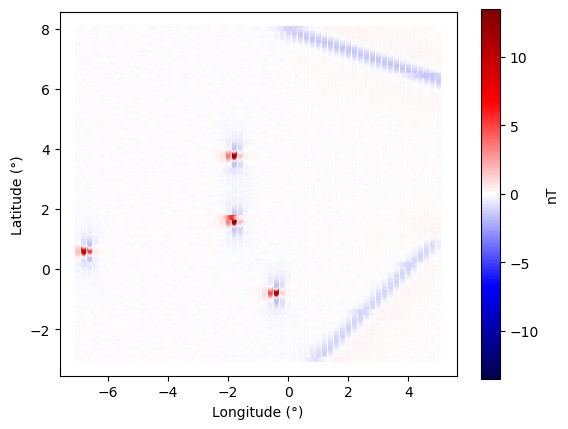

In [13]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [14]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 2e4
)



damping = 1e-5
eqs_inc = 90
eqs_dec = 0
eqs_dipole_unit = hm.magnetic_angles_to_vec(1,eqs_inc, eqs_dec)

In [15]:
window_size = 4
_, source_indices = vd.rolling_window(equivalent_layer, size=window_size, spacing=window_size / 2)
_, data_indices = vd.rolling_window(coordinates, size=window_size, spacing=window_size / 2)
source_indices = [i[0] for i in source_indices.ravel()]
data_indices = [i[0] for i in data_indices.ravel()]

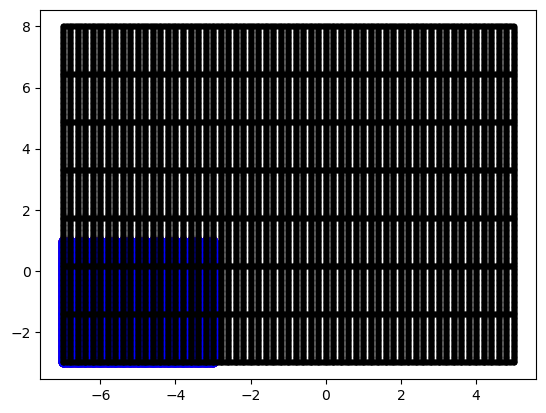

In [16]:
i = 0

data_coord = tuple(c[data_indices[i]] for c in coordinates)
source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)

plt.plot(*data_coord[:2], "or")
plt.plot(*source_coord[:2], "ob")
plt.plot(*coordinates[:2], ".k")

In [17]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.dipole_magnetic_geodetic(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [18]:
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region_airbone, shape=(150,150), extra_coords= + 200))

grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dike, np.full(dike_size, -1e11))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dike_2, np.full(dike_size, -1e11))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dipoles, np.full(n_dipoles ,1e12))

In [19]:
def fit(coordinates, data, eqs_source_coords, damping, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):
    A = sph.jacobian(
        coordinates, 
        eqs_source_coords,
        eqs_inc, eqs_dec,
        inclination_main_field, declination_main_field
    )
    eqs_dipole_moment_amplitude = sph.calculate_coefficients(
        data, A, damping=damping,
    )
    return eqs_dipole_moment_amplitude

In [20]:
rmses = []
residuals = magnetic_anomaly.copy()
scale = vd.maxabs(magnetic_anomaly)
dipole_moment_amp = np.zeros_like(equivalent_layer[0])

predicted_total_field_grid = grided_dd_anomaly.copy()

window_indices = list(range(len(data_indices)))
np.random.shuffle(window_indices)
for i in window_indices:
    data_coord = tuple(c[data_indices[i]] for c in coordinates)
    source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)
    
    eqs_dipole_moment_amp = fit(
        data_coord,
        residuals[data_indices[i]],
        source_coord,
        damping,
        eqs_inc,
        eqs_dec,
        inclination,
        declination
    )
    dipole_moment_amp[source_indices[i]] += eqs_dipole_moment_amp
    eqs_dipole_moment =  np.array( hm.magnetic_angles_to_vec(
    np.full(eqs_dipole_moment_amp.size, 1),  
    np.full(eqs_dipole_moment_amp.size, inclination),  
    np.full(eqs_dipole_moment_amp.size, declination)   
))


    predicted_total_field_anomaly = hm.total_field_anomaly(
        sph.dipole_magnetic_geodetic(coordinates, source_coord, eqs_dipole_moment),
          inclination, declination)
    residuals -= predicted_total_field_anomaly
    
    
    predicted_total_field_grid -= hm.total_field_anomaly(
        sph.dipole_magnetic_geodetic(grid_coord, source_coord, eqs_dipole_moment),
        inclination, declination,
    )


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5), sharey=True, layout="constrained")  


im0 = axes[0].tripcolor(*grid_coord[:2], predicted_total_field_grid, cmap="seismic", vmin=-scale, vmax=scale)
axes[0].set_title("Predicted Total Field Anomaly")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

im1 = axes[1].tripcolor(*grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
axes[1].set_title("True Total Field Anomaly")
axes[1].set_aspect("equal")


diff_grid_tfa = grided_dd_anomaly - predicted_total_field_grid
im2 = axes[2].tripcolor(*grid_coord[:2], diff_grid_tfa, cmap="seismic")
axes[2].set_title(f"Interpolation Error")
axes[2].set_aspect("equal")


cb0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", aspect=40)
cb0.set_label("nT")
cb1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", aspect=40)
cb1.set_label("nT")
cb2 = fig.colorbar(im2, ax=axes[2], orientation="horizontal", aspect=40)
cb2.set_label("nT")

for ax in axes.ravel():
    ax.set_xlim(*region_airbone[:2])
    ax.set_ylim(*region_airbone[2:])
    ax.set_xlabel("Longitude")

for ax, label in zip(axes, "abc"):
    ax.text(0.0, 1.03, f"{label})", transform=ax.transAxes)

plt.savefig("total_field_anomaly_inversion-gb.png", dpi=300, format='png')
plt.show()

